In [44]:
import os
from pathlib import Path

import ipynbname

primary_path = Path(ipynbname.path()).parent.parent.parent
print("Changing working directory to: ", primary_path)
os.chdir(primary_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set Global matplotlib params
# plt.rcParams['font.family'] = "serif"
# plt.rcParams['font.serif'] = ["New Computer Modern"]
# plt.rcParams['text.usetex'] = False

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["New Computer Modern", "NewComputerModern"],
#     "mathtext.fontset": "custom",
#     "mathtext.rm": "New Computer Modern",
#     "mathtext.it": "New Computer Modern:italic",
#     "mathtext.bf": "New Computer Modern:bold",
# })

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Changing working directory to:  /Users/sylvia/dev/aeon


In [15]:
# Load relavent data files
family1 = pd.read_csv("scripts/data/FD_24_fam_1.csv")
pstar1 = np.min(family1["param"]) - 1e-16

family2 = pd.read_csv("scripts/data/FD_19_fam_2.csv")
pstar2 = np.min(family2["param"]) - 1e-16
family2 = family2[(family2["param"] - pstar2) > 1e-10]

family3 = pd.read_csv("scripts/data/FD_19_fam_3.csv")
pstar3 = np.min(family3["param"]) - 1e-16
family3 = family3[(family3["param"] - pstar3) > 1e-10]

phi_origin1 = pd.read_csv("scripts/data/FD_phi_origin.txt", sep=" ")
tstar1 = np.max(phi_origin1["proper_time"])
phi_origin1 = phi_origin1[phi_origin1["proper_time"] < tstar1]

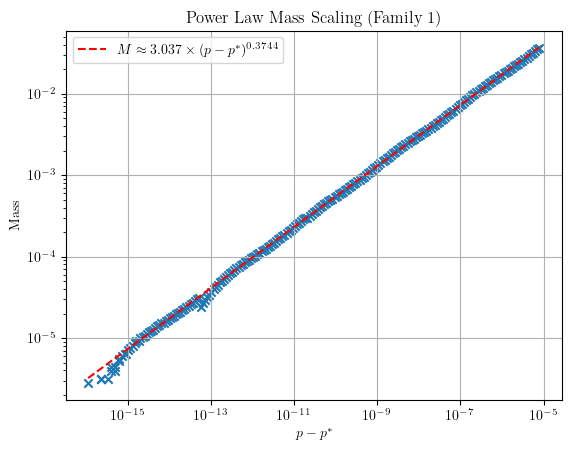

In [27]:
fig, ax = plt.subplots(1, 1)


pstar = np.min(family1["param"]) - 1e-16
fit =  np.exp(1.111) * np.pow(family1["param"] - pstar, 0.3744)

ax.scatter(family1["param"] - pstar, family1['mass'], marker="x")
ax.plot(family1["param"] - pstar, fit, color="red", linestyle="dashed", label=r"$M \approx 3.037 \times (p - p^*)^{0.3744}$")
ax.set_title("Power Law Mass Scaling (Family 1)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$p - p^*$")
ax.set_ylabel("Mass")
ax.legend()
# ax.set_xlim(10e-14, 10e-5)
ax.grid(True)
plt.show()

# fig.savefig("figures/mass_scaling_family1.pdf", bbox_inches='tight')
fig.savefig("figures/mass_scaling_family1.pdf", bbox_inches='tight')
# fig.savefig("figures/mass_scaling_family1.png", bbox_inches='tight')


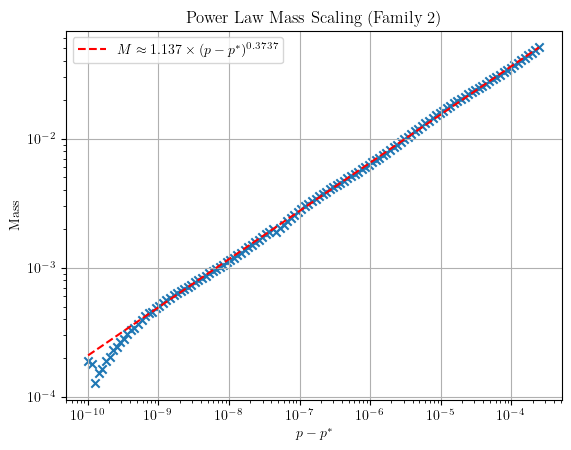

In [28]:
fig, ax = plt.subplots(1, 1)
fit =  np.exp(0.1285) * np.pow(family2["param"] - pstar2, 0.3737)

ax.scatter(family2["param"] - pstar2, family2['mass'], marker="x")
ax.plot(family2["param"] - pstar2, fit, color="red", linestyle="dashed", label=r"$M \approx 1.137 \times (p - p^*)^{0.3737}$")
ax.set_title("Power Law Mass Scaling (Family 2)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$p - p^*$")
ax.set_ylabel("Mass")
ax.legend()
# ax.set_xlim(1e-10, 1e-5)
# ax.set_ylim(10**(-3.75), 10**(-1.75))
ax.grid(True)
plt.show()

fig.savefig("figures/mass_scaling_family2.pdf", bbox_inches='tight')


1.5023041056619504


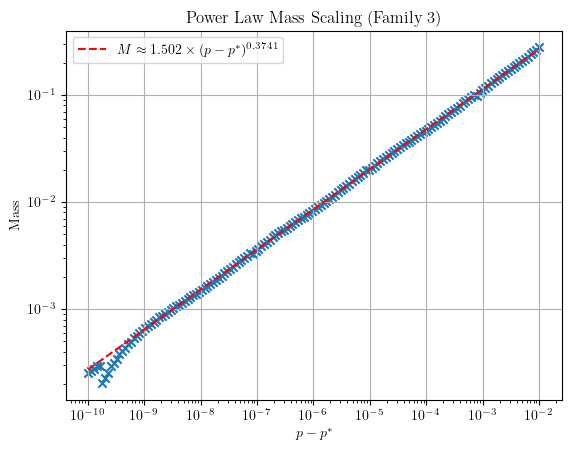

In [29]:
fig, ax = plt.subplots(1, 1)

fit =  np.exp(0.407) * np.pow(family3["param"] - pstar3, 0.3741)

print(np.exp(0.407))

ax.scatter(family3["param"] - pstar3, family3['mass'], marker="x")
ax.plot(family3["param"] - pstar3, fit, color="red", linestyle="dashed", label=r"$M \approx 1.502 \times (p - p^*)^{0.3741}$")
ax.set_title("Power Law Mass Scaling (Family 3)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$p - p^*$")
ax.set_ylabel("Mass")
ax.legend()
ax.grid(True)
plt.show()

fig.savefig("figures/mass_scaling_family3.pdf", bbox_inches='tight')

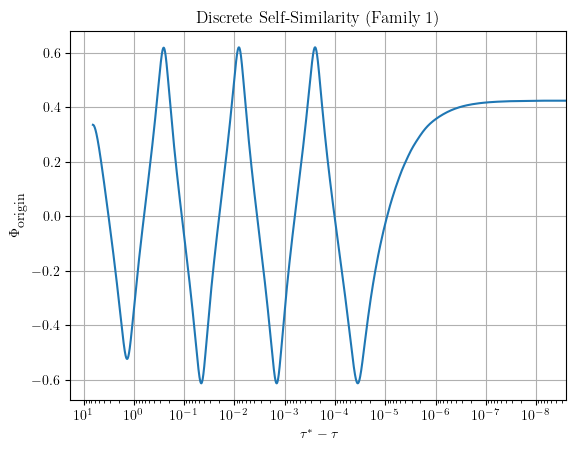

In [55]:
fig, ax = plt.subplots(1, 1)

ax.plot(tstar1 - 0.605e-3 - phi_origin1["proper_time"], phi_origin1["value"])

ax.set_title("Discrete Self-Similarity (Family 1)")
ax.set_ylabel(r"$\Phi_\textrm{origin}$")
ax.set_xscale('log')
ax.set_xlabel(r"$\tau^* - \tau$")
ax.invert_xaxis() 
ax.grid(True)

ax.set_xticks([1e1, 1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8])
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=list(np.arange(2, 10) * 0.1), numticks=100))
# Ensure they don't have labels to avoid clutter
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

plt.show()
fig.savefig("figures/self_similarity_family1.pdf", bbox_inches='tight')